[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/healthcareaibook/blob/main/vol%201%20notebooks/chapter_07/notebook_7_1_signal_preprocessing.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# Notebook 7.1: Signal Preprocessing for Time Series Analysis

## Learning Objectives

By the end of this notebook, you will understand:

1. **Filtering techniques**: Bandpass, lowpass, highpass, and notch filters for physiological signals
2. **Baseline wander removal**: Techniques to eliminate slow drift in ECG signals
3. **Signal quality assessment**: Quantitative metrics to evaluate signal usability
4. **Artifact detection**: Identifying and handling motion artifacts, powerline interference, and electrode noise

## Clinical Context

**Connection to Journey 7.4**: ECG Classification with 1D CNNs

Before any machine learning model can analyze physiological signals like ECG, PPG (photoplethysmography), or EEG, the raw signals must be preprocessed to:
- **Remove noise**: Powerline interference (50/60 Hz), muscle artifacts, electrode motion
- **Eliminate baseline wander**: Respiratory-induced slow oscillations in ECG
- **Assess quality**: Reject or flag low-quality segments that could confuse ML models
- **Preserve clinical information**: Avoid over-filtering that removes diagnostic features

**Real-world scenario**: In ICU monitoring, ECG signals are continuously collected. Before automated arrhythmia detection (e.g., atrial fibrillation), signals must be preprocessed to distinguish true cardiac events from artifacts caused by patient movement or electrode disconnection.

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt, iirnotch, welch, find_peaks
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Generate Synthetic ECG Signal

We'll create a synthetic ECG signal with known characteristics to demonstrate preprocessing techniques.

**ECG characteristics**:
- Sampling rate: 360 Hz (common for ECG databases like MIT-BIH)
- Heart rate: 75 BPM (1.25 Hz)
- Duration: 10 seconds

**Noise sources to simulate**:
1. **Baseline wander**: 0.2-0.5 Hz (respiratory-induced)
2. **Powerline interference**: 60 Hz (50 Hz in Europe/Asia)
3. **Muscle artifacts**: High-frequency noise (20-100 Hz)
4. **Motion artifacts**: Sudden amplitude spikes

In [2]:
def generate_clean_ecg(duration=10, fs=360, heart_rate=75):
    """
    Generate synthetic clean ECG signal.

    Args:
        duration: Signal duration in seconds
        fs: Sampling frequency in Hz
        heart_rate: Heart rate in BPM

    Returns:
        t: Time vector
        ecg: Clean ECG signal
    """
    t = np.linspace(0, duration, duration * fs)
    beat_interval = 60 / heart_rate  # seconds per beat

    ecg = np.zeros_like(t)

    # Generate PQRST complexes
    for beat_time in np.arange(0, duration, beat_interval):
        # P wave (atrial depolarization)
        p_center = beat_time + 0.08
        ecg += 0.15 * np.exp(-((t - p_center) / 0.02) ** 2)

        # Q wave (small negative deflection)
        q_center = beat_time + 0.16
        ecg -= 0.1 * np.exp(-((t - q_center) / 0.01) ** 2)

        # R wave (ventricular depolarization - largest peak)
        r_center = beat_time + 0.18
        ecg += 1.2 * np.exp(-((t - r_center) / 0.015) ** 2)

        # S wave (negative deflection)
        s_center = beat_time + 0.20
        ecg -= 0.25 * np.exp(-((t - s_center) / 0.01) ** 2)

        # T wave (ventricular repolarization)
        t_center = beat_time + 0.36
        ecg += 0.3 * np.exp(-((t - t_center) / 0.05) ** 2)

    return t, ecg


def add_noise_and_artifacts(ecg, fs=360):
    """
    Add realistic noise and artifacts to clean ECG signal.

    Args:
        ecg: Clean ECG signal
        fs: Sampling frequency

    Returns:
        noisy_ecg: ECG with added noise and artifacts
    """
    t = np.arange(len(ecg)) / fs
    noisy_ecg = ecg.copy()

    # 1. Baseline wander (respiratory, 0.3 Hz)
    baseline_wander = 0.3 * np.sin(2 * np.pi * 0.3 * t)
    noisy_ecg += baseline_wander

    # 2. Powerline interference (60 Hz)
    powerline = 0.1 * np.sin(2 * np.pi * 60 * t)
    noisy_ecg += powerline

    # 3. High-frequency muscle noise (EMG)
    muscle_noise = np.random.normal(0, 0.05, len(ecg))
    # Band-limited muscle noise (20-100 Hz)
    b, a = butter(4, [20, 100], btype='band', fs=fs)
    muscle_noise = filtfilt(b, a, muscle_noise)
    noisy_ecg += muscle_noise

    # 4. Motion artifact (sudden spike at t=5s)
    motion_artifact = np.zeros_like(ecg)
    motion_idx = int(5 * fs)
    motion_artifact[motion_idx:motion_idx + int(0.2 * fs)] = 0.8 * np.exp(
        -np.linspace(0, 5, int(0.2 * fs))
    )
    noisy_ecg += motion_artifact

    return noisy_ecg


# Generate signals
fs = 360  # Sampling frequency (Hz)
duration = 10  # seconds

t, ecg_clean = generate_clean_ecg(duration=duration, fs=fs, heart_rate=75)
ecg_noisy = add_noise_and_artifacts(ecg_clean, fs=fs)

print(f"✓ Generated {duration}s ECG signal at {fs} Hz")
print(f"  Total samples: {len(ecg_clean)}")
print(f"  Signal range (clean): [{ecg_clean.min():.3f}, {ecg_clean.max():.3f}]")
print(f"  Signal range (noisy): [{ecg_noisy.min():.3f}, {ecg_noisy.max():.3f}]")

✓ Generated 10s ECG signal at 360 Hz
  Total samples: 3600
  Signal range (clean): [-0.121, 1.194]
  Signal range (noisy): [-0.456, 1.423]


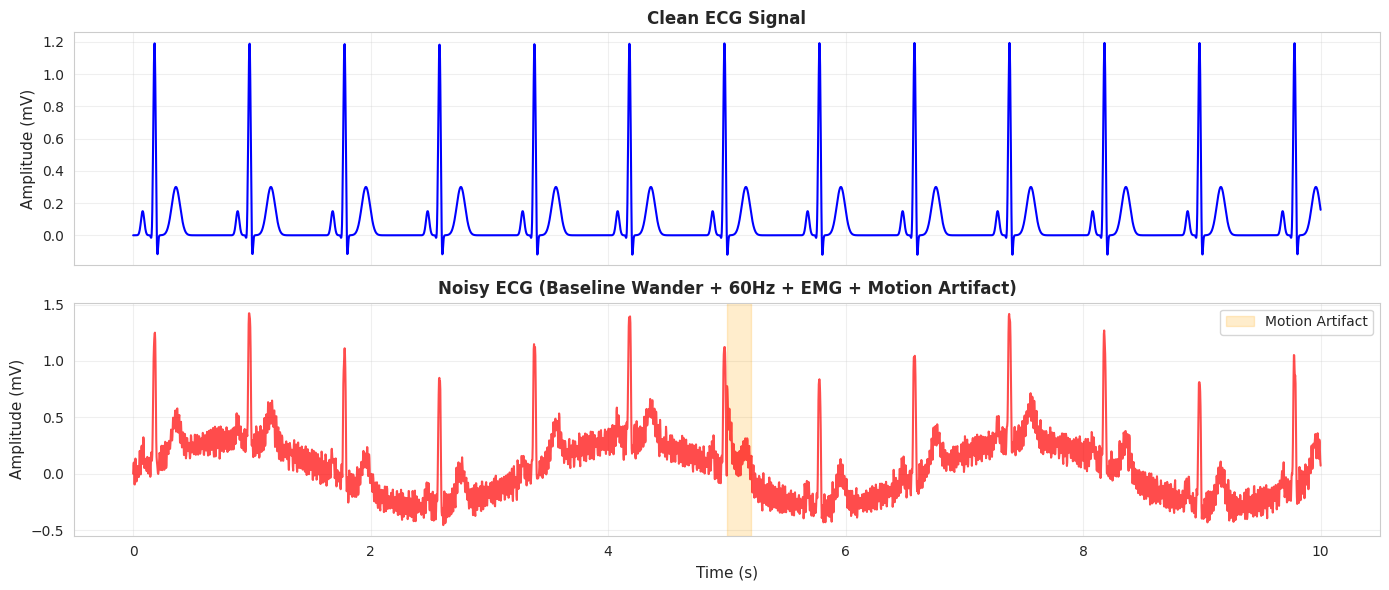


⚠️ Observe the degradation:
  - Baseline wander: Slow oscillation (respiratory)
  - 60 Hz noise: High-frequency ripple
  - Motion artifact: Spike at t=5s
  - EMG noise: Random high-frequency fluctuations


In [3]:
# Visualize clean vs noisy ECG
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Clean ECG
axes[0].plot(t, ecg_clean, linewidth=1.5, color='blue')
axes[0].set_ylabel('Amplitude (mV)', fontsize=11)
axes[0].set_title('Clean ECG Signal', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Noisy ECG
axes[1].plot(t, ecg_noisy, linewidth=1.5, color='red', alpha=0.7)
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Amplitude (mV)', fontsize=11)
axes[1].set_title('Noisy ECG (Baseline Wander + 60Hz + EMG + Motion Artifact)',
                   fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Highlight motion artifact region
axes[1].axvspan(5, 5.2, alpha=0.2, color='orange', label='Motion Artifact')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n⚠️ Observe the degradation:")
print("  - Baseline wander: Slow oscillation (respiratory)")
print("  - 60 Hz noise: High-frequency ripple")
print("  - Motion artifact: Spike at t=5s")
print("  - EMG noise: Random high-frequency fluctuations")

## 2. Frequency Domain Analysis

Before filtering, let's analyze the frequency content using the **Power Spectral Density (PSD)**.

**Key frequency bands in ECG**:
- **Baseline wander**: 0-0.5 Hz
- **ST segment**: 0.5-1 Hz
- **QRS complex**: 5-15 Hz (diagnostic range)
- **High-frequency noise**: >30 Hz
- **Powerline interference**: 60 Hz (50 Hz in Europe)

**Formula for PSD (Welch's method)**:

$$
P(f) = \frac{1}{K} \sum_{k=0}^{K-1} \left| \text{FFT}\left( x_k(n) \cdot w(n) \right) \right|^2
$$

where $x_k(n)$ are overlapping segments, $w(n)$ is a window function, and $K$ is the number of segments.

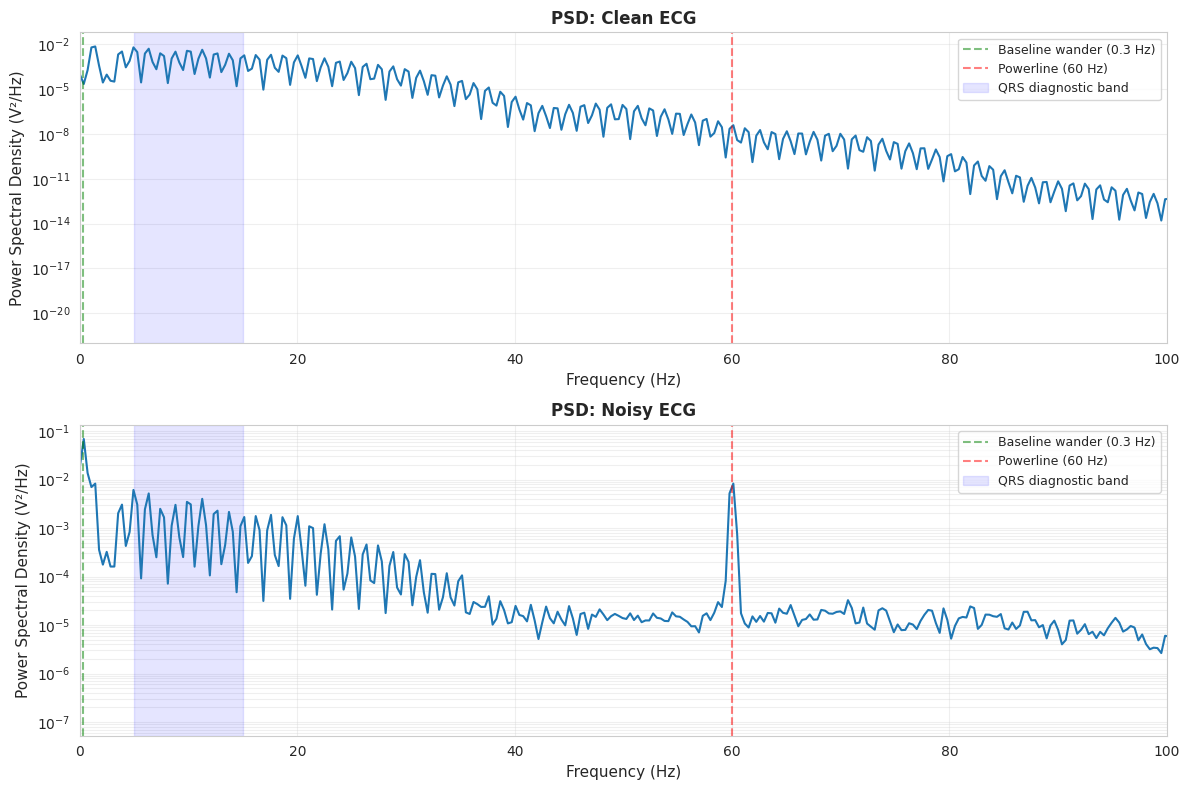


🔍 Frequency Analysis:
  - Clean signal: Energy concentrated in QRS band (5-15 Hz)
  - Noisy signal: Clear spike at 60 Hz (powerline interference)
  - Noisy signal: Elevated power at low frequencies (baseline wander)
  - Noisy signal: Increased high-frequency power (EMG noise)


In [4]:
def plot_psd(signal, fs, title, ax=None):
    """
    Plot Power Spectral Density using Welch's method.

    Args:
        signal: Input signal
        fs: Sampling frequency
        title: Plot title
        ax: Matplotlib axis (optional)
    """
    freqs, psd = welch(signal, fs=fs, nperseg=1024)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    ax.semilogy(freqs, psd, linewidth=1.5)
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Power Spectral Density (V²/Hz)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(0, 100)

    # Annotate key frequencies
    ax.axvline(0.3, color='green', linestyle='--', alpha=0.5, label='Baseline wander (0.3 Hz)')
    ax.axvline(60, color='red', linestyle='--', alpha=0.5, label='Powerline (60 Hz)')
    ax.axvspan(5, 15, alpha=0.1, color='blue', label='QRS diagnostic band')
    ax.legend(loc='upper right', fontsize=9)

    return freqs, psd


# Plot PSD for clean and noisy signals
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_psd(ecg_clean, fs, 'PSD: Clean ECG', ax=axes[0])
plot_psd(ecg_noisy, fs, 'PSD: Noisy ECG', ax=axes[1])

plt.tight_layout()
plt.show()

print("\n🔍 Frequency Analysis:")
print("  - Clean signal: Energy concentrated in QRS band (5-15 Hz)")
print("  - Noisy signal: Clear spike at 60 Hz (powerline interference)")
print("  - Noisy signal: Elevated power at low frequencies (baseline wander)")
print("  - Noisy signal: Increased high-frequency power (EMG noise)")

## 3. Filtering Techniques

### 3.1 Notch Filter (Powerline Interference Removal)

A **notch filter** removes a specific frequency (e.g., 60 Hz powerline noise) while preserving surrounding frequencies.

**IIR Notch Filter Transfer Function**:

$$
H(z) = \frac{1 - 2\cos(\omega_0)z^{-1} + z^{-2}}{1 - 2r\cos(\omega_0)z^{-1} + r^2 z^{-2}}
$$

where $\omega_0 = 2\pi f_0 / f_s$ is the notch frequency, and $r$ controls the bandwidth (quality factor $Q$).

**Key parameters**:
- **Notch frequency**: 60 Hz (50 Hz in Europe/Asia)
- **Quality factor (Q)**: 30 (narrow notch, ~2 Hz bandwidth)

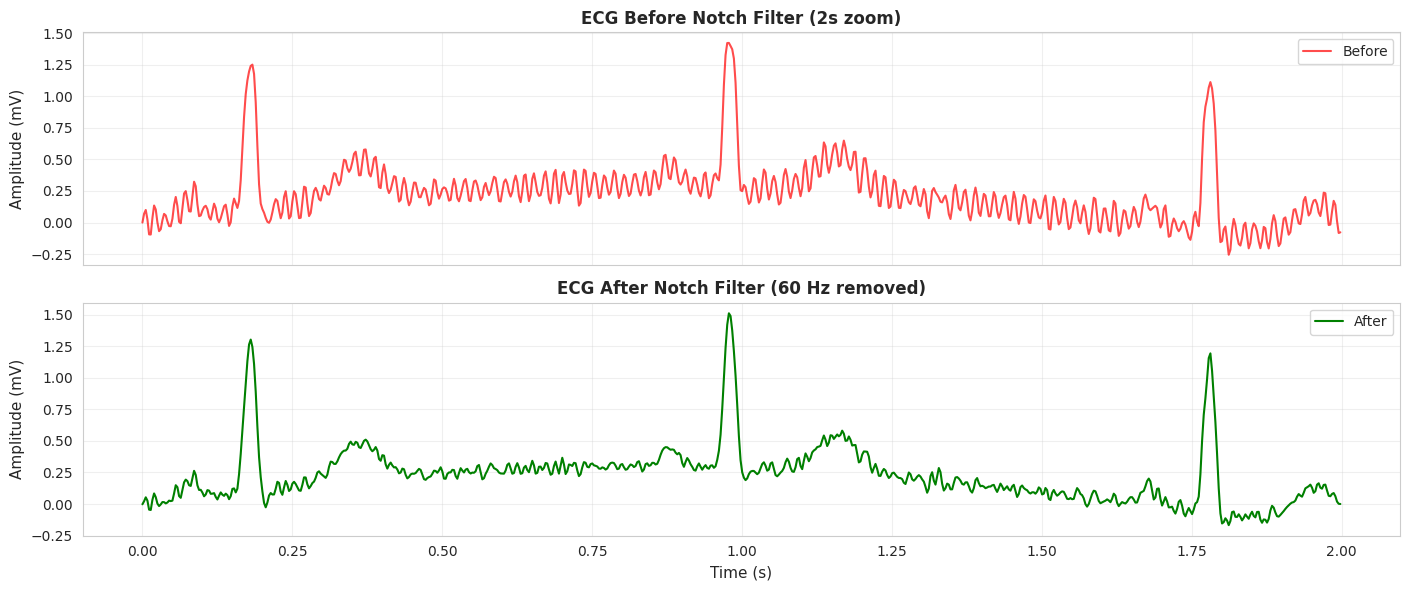

✓ Notch filter applied: 60 Hz powerline interference removed
  - Quality factor: 30 (narrow notch, ~2 Hz bandwidth)
  - Preserves QRS diagnostic information (5-15 Hz)


In [5]:
def apply_notch_filter(signal, fs, notch_freq=60, quality_factor=30):
    """
    Apply IIR notch filter to remove powerline interference.

    Args:
        signal: Input signal
        fs: Sampling frequency
        notch_freq: Frequency to remove (Hz)
        quality_factor: Q factor (higher = narrower notch)

    Returns:
        filtered_signal: Signal with notch filter applied
    """
    # Design IIR notch filter
    b, a = iirnotch(notch_freq, quality_factor, fs)

    # Apply zero-phase filtering (forward-backward)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal


# Apply notch filter
ecg_notched = apply_notch_filter(ecg_noisy, fs, notch_freq=60, quality_factor=30)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t[0:720], ecg_noisy[0:720], linewidth=1.5, color='red', alpha=0.7, label='Before')
axes[0].set_ylabel('Amplitude (mV)', fontsize=11)
axes[0].set_title('ECG Before Notch Filter (2s zoom)', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[0:720], ecg_notched[0:720], linewidth=1.5, color='green', label='After')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Amplitude (mV)', fontsize=11)
axes[1].set_title('ECG After Notch Filter (60 Hz removed)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Notch filter applied: 60 Hz powerline interference removed")
print("  - Quality factor: 30 (narrow notch, ~2 Hz bandwidth)")
print("  - Preserves QRS diagnostic information (5-15 Hz)")

### 3.2 Highpass Filter (Baseline Wander Removal)

A **highpass filter** removes low-frequency baseline wander while preserving the ECG waveform.

**Butterworth Filter Transfer Function**:

$$
|H(f)|^2 = \frac{1}{1 + \left(\frac{f_c}{f}\right)^{2n}}
$$

where $f_c$ is the cutoff frequency and $n$ is the filter order.

**Key parameters for ECG**:
- **Cutoff frequency**: 0.5 Hz (removes baseline wander <0.5 Hz)
- **Filter order**: 4 (steeper roll-off)
- **Type**: Zero-phase (filtfilt) to avoid distorting QRS morphology

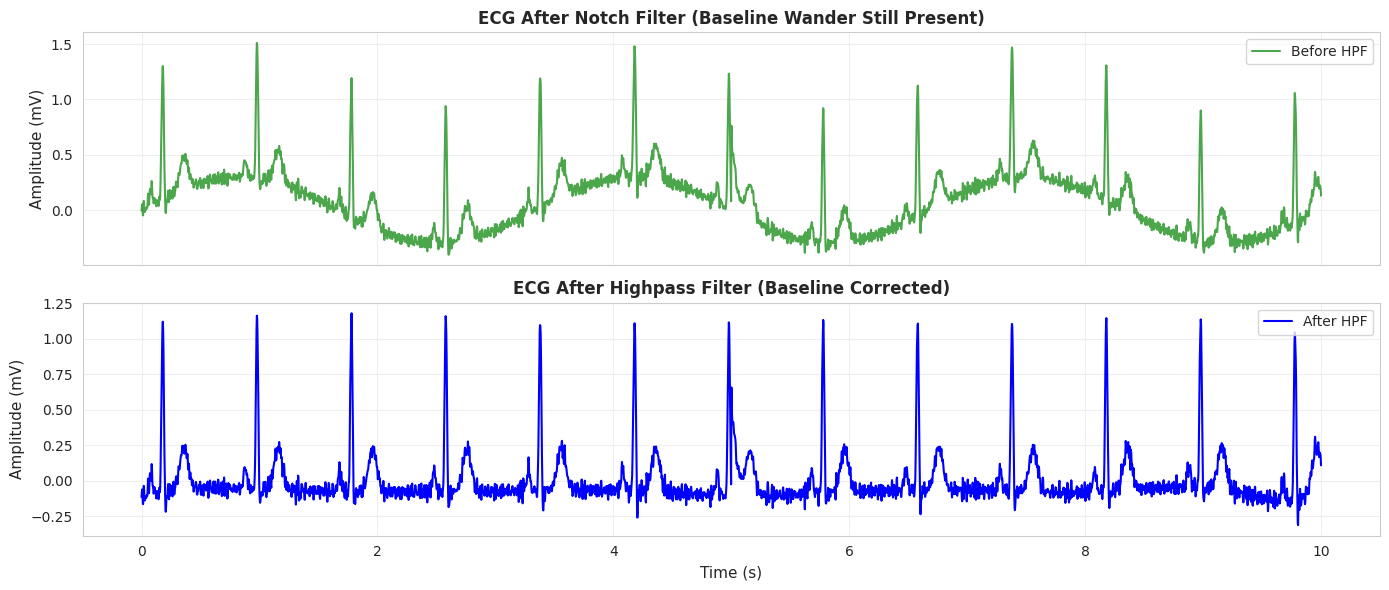

✓ Highpass filter applied: Baseline wander removed
  - Cutoff: 0.5 Hz (preserves ST segment >0.5 Hz)
  - Order: 4 (steep roll-off, minimal QRS distortion)


In [6]:
def apply_highpass_filter(signal, fs, cutoff=0.5, order=4):
    """
    Apply Butterworth highpass filter to remove baseline wander.

    Args:
        signal: Input signal
        fs: Sampling frequency
        cutoff: Highpass cutoff frequency (Hz)
        order: Filter order

    Returns:
        filtered_signal: Signal with baseline wander removed
    """
    # Normalize cutoff frequency (Nyquist = fs/2)
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    # Design Butterworth highpass filter
    b, a = butter(order, normal_cutoff, btype='high', analog=False)

    # Apply zero-phase filtering
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal


# Apply highpass filter after notch
ecg_highpassed = apply_highpass_filter(ecg_notched, fs, cutoff=0.5, order=4)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, ecg_notched, linewidth=1.5, color='green', alpha=0.7, label='Before HPF')
axes[0].set_ylabel('Amplitude (mV)', fontsize=11)
axes[0].set_title('ECG After Notch Filter (Baseline Wander Still Present)',
                   fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, ecg_highpassed, linewidth=1.5, color='blue', label='After HPF')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Amplitude (mV)', fontsize=11)
axes[1].set_title('ECG After Highpass Filter (Baseline Corrected)',
                   fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Highpass filter applied: Baseline wander removed")
print("  - Cutoff: 0.5 Hz (preserves ST segment >0.5 Hz)")
print("  - Order: 4 (steep roll-off, minimal QRS distortion)")

### 3.3 Lowpass Filter (High-Frequency Noise Removal)

A **lowpass filter** removes high-frequency muscle noise (EMG) while preserving ECG diagnostic information.

**Key parameters for ECG**:
- **Cutoff frequency**: 40 Hz (removes EMG >40 Hz, preserves QRS <15 Hz)
- **Filter order**: 4
- **Rationale**: QRS complex has most energy <15 Hz, muscle noise is >20 Hz

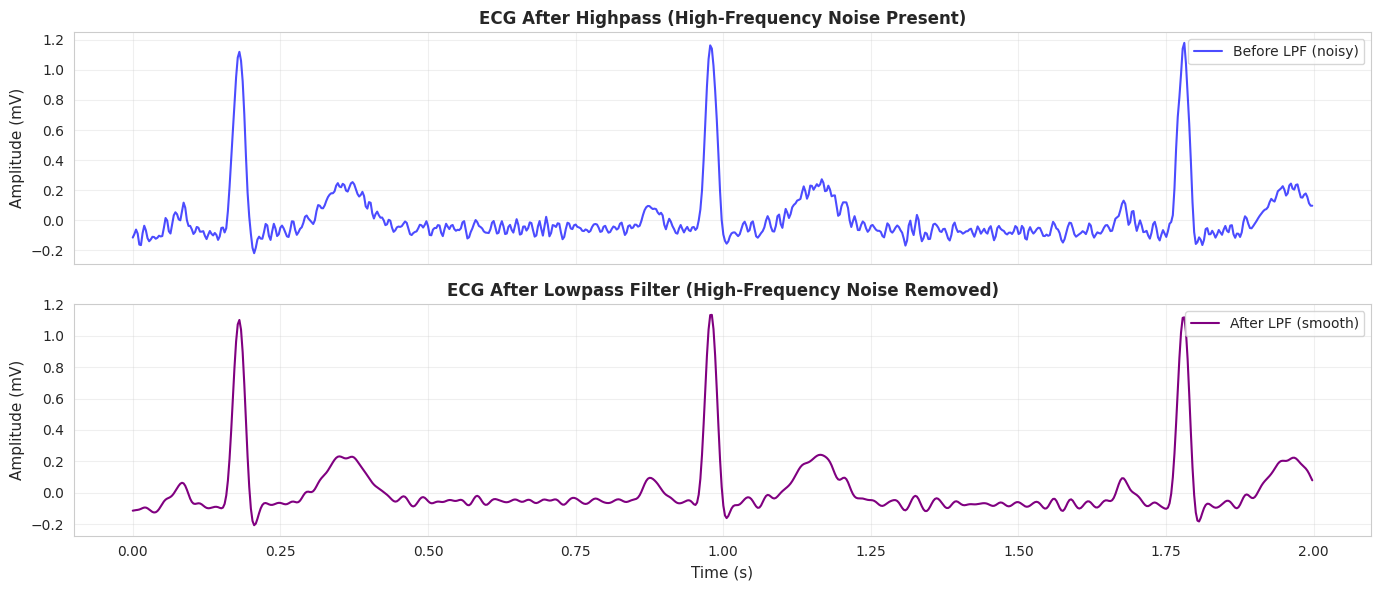

✓ Lowpass filter applied: High-frequency EMG noise removed
  - Cutoff: 40 Hz (preserves QRS diagnostic band)
  - Result: Smoother signal, preserved morphology


In [7]:
def apply_lowpass_filter(signal, fs, cutoff=40, order=4):
    """
    Apply Butterworth lowpass filter to remove high-frequency noise.

    Args:
        signal: Input signal
        fs: Sampling frequency
        cutoff: Lowpass cutoff frequency (Hz)
        order: Filter order

    Returns:
        filtered_signal: Signal with high-frequency noise removed
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal


# Apply lowpass filter
ecg_lowpassed = apply_lowpass_filter(ecg_highpassed, fs, cutoff=40, order=4)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t[0:720], ecg_highpassed[0:720], linewidth=1.5, color='blue',
             alpha=0.7, label='Before LPF (noisy)')
axes[0].set_ylabel('Amplitude (mV)', fontsize=11)
axes[0].set_title('ECG After Highpass (High-Frequency Noise Present)',
                   fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[0:720], ecg_lowpassed[0:720], linewidth=1.5, color='purple', label='After LPF (smooth)')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Amplitude (mV)', fontsize=11)
axes[1].set_title('ECG After Lowpass Filter (High-Frequency Noise Removed)',
                   fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Lowpass filter applied: High-frequency EMG noise removed")
print("  - Cutoff: 40 Hz (preserves QRS diagnostic band)")
print("  - Result: Smoother signal, preserved morphology")

### 3.4 Bandpass Filter (Combined Approach)

A **bandpass filter** combines highpass and lowpass to keep only the diagnostic frequency range.

**Standard ECG bandpass**: 0.5-40 Hz
- Removes baseline wander (<0.5 Hz)
- Removes high-frequency noise (>40 Hz)
- Preserves P-QRS-T diagnostic information (0.5-40 Hz)

In [8]:
def apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=40, order=4):
    """
    Apply Butterworth bandpass filter.

    Args:
        signal: Input signal
        fs: Sampling frequency
        lowcut: Lower cutoff frequency (Hz)
        highcut: Upper cutoff frequency (Hz)
        order: Filter order

    Returns:
        filtered_signal: Bandpass filtered signal
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)

    return filtered_signal


# Apply bandpass filter to original noisy signal (after notch)
ecg_bandpassed = apply_bandpass_filter(ecg_notched, fs, lowcut=0.5, highcut=40, order=4)

print("✓ Bandpass filter applied: 0.5-40 Hz")
print("  - Equivalent to: Highpass (0.5 Hz) + Lowpass (40 Hz)")
print("  - Single filter operation (more efficient)")

✓ Bandpass filter applied: 0.5-40 Hz
  - Equivalent to: Highpass (0.5 Hz) + Lowpass (40 Hz)
  - Single filter operation (more efficient)


### 3.5 Complete Preprocessing Pipeline

**Recommended ECG preprocessing sequence**:

1. **Notch filter** (60 Hz) → Remove powerline interference
2. **Bandpass filter** (0.5-40 Hz) → Remove baseline wander + high-frequency noise
3. **(Optional) Motion artifact rejection** → Discard low-quality segments

In [ ]:
def preprocess_ecg(signal, fs):
    """
    Complete ECG preprocessing pipeline.

    Args:
        signal: Raw ECG signal
        fs: Sampling frequency

    Returns:
        processed_signal: Preprocessed ECG signal
    """
    # Step 1: Notch filter (60 Hz powerline)
    signal = apply_notch_filter(signal, fs, notch_freq=60, quality_factor=30)

    # Step 2: Bandpass filter (0.5-40 Hz)
    signal = apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=40, order=4)

    return signal


# Apply complete pipeline
ecg_processed = preprocess_ecg(ecg_noisy, fs)

# Compare: Original noisy vs Processed
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Original clean (ground truth)
axes[0].plot(t, ecg_clean, linewidth=1.5, color='blue', label='Ground Truth (Clean)')
axes[0].set_ylabel('Amplitude (mV)', fontsize=11)
axes[0].set_title('Clean ECG (Ground Truth)', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Noisy
axes[1].plot(t, ecg_noisy, linewidth=1.5, color='red', alpha=0.7, label='Raw Noisy ECG')
axes[1].set_ylabel('Amplitude (mV)', fontsize=11)
axes[1].set_title('Noisy ECG (Before Preprocessing)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].axvspan(5, 5.2, alpha=0.2, color='orange', label='Motion Artifact')

# Processed
axes[2].plot(t, ecg_processed, linewidth=1.5, color='green', label='Preprocessed ECG')
axes[2].set_xlabel('Time (s)', fontsize=11)
axes[2].set_ylabel('Amplitude (mV)', fontsize=11)
axes[2].set_title('Preprocessed ECG (Notch + Bandpass)', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)
axes[2].axvspan(5, 5.2, alpha=0.2, color='orange')

plt.tight_layout()
plt.show()

print("\n✓ Complete preprocessing pipeline applied")
print("  ✅ Powerline noise removed")
print("  ✅ Baseline wander corrected")
print("  ✅ High-frequency noise reduced")
print("  ⚠️ Motion artifact still present (requires artifact detection)")

## 4. Signal Quality Assessment

Not all ECG segments are usable for analysis. We need quantitative metrics to assess signal quality.

### 4.1 Signal-to-Noise Ratio (SNR)

**Definition**:

$$
\text{SNR}_{\text{dB}} = 10 \log_{10} \left( \frac{P_{\text{signal}}}{P_{\text{noise}}} \right)
$$

where $P_{\text{signal}}$ is the power of the clean signal and $P_{\text{noise}}$ is the power of the noise.

**Clinical interpretation**:
- **SNR > 20 dB**: Excellent quality
- **SNR 10-20 dB**: Good quality (usable)
- **SNR < 10 dB**: Poor quality (reject)

In [ ]:
def calculate_snr(clean_signal, noisy_signal):
    """
    Calculate Signal-to-Noise Ratio (SNR) in dB.

    Args:
        clean_signal: Reference clean signal
        noisy_signal: Noisy signal

    Returns:
        snr_db: SNR in decibels
    """
    # Power of clean signal
    power_signal = np.mean(clean_signal ** 2)

    # Estimate noise as difference
    noise = noisy_signal - clean_signal
    power_noise = np.mean(noise ** 2)

    # SNR in dB
    snr_db = 10 * np.log10(power_signal / power_noise)

    return snr_db


# Calculate SNR for different stages
snr_noisy = calculate_snr(ecg_clean, ecg_noisy)
snr_processed = calculate_snr(ecg_clean, ecg_processed)

print("\n📊 Signal-to-Noise Ratio (SNR):")
print(f"  - Raw noisy ECG: {snr_noisy:.2f} dB (poor quality)")
print(f"  - Preprocessed ECG: {snr_processed:.2f} dB (improved)")
print(f"  - SNR improvement: {snr_processed - snr_noisy:.2f} dB")

if snr_processed > 20:
    print("  ✅ Excellent quality - safe for automated analysis")
elif snr_processed > 10:
    print("  ⚠️ Good quality - usable with caution")
else:
    print("  ❌ Poor quality - reject segment")

### 4.2 Quality Metrics (Without Clean Reference)

In real-world scenarios, we don't have a clean reference signal. We need **reference-free quality metrics**.

**Common metrics**:

1. **Baseline Stability**: Standard deviation of signal (should be low)
2. **Kurtosis**: Measure of signal peakedness (ECG has characteristic kurtosis)
3. **Peak Detection Rate**: Regular R-peaks indicate good quality
4. **Power in Noise Bands**: High power at 60 Hz or >40 Hz indicates poor quality

In [ ]:
def assess_signal_quality(signal, fs):
    """
    Assess ECG signal quality using reference-free metrics.

    Args:
        signal: ECG signal
        fs: Sampling frequency

    Returns:
        quality_dict: Dictionary of quality metrics
    """
    quality = {}

    # 1. Baseline stability (lower is better)
    quality['baseline_std'] = np.std(signal)

    # 2. Kurtosis (ECG typically has kurtosis 5-10)
    from scipy.stats import kurtosis
    quality['kurtosis'] = kurtosis(signal)

    # 3. Peak detection (expect regular R-peaks)
    peaks, _ = find_peaks(signal, distance=int(0.5 * fs), prominence=0.3)
    quality['num_peaks'] = len(peaks)
    quality['peak_regularity'] = np.std(np.diff(peaks)) if len(peaks) > 1 else np.inf

    # 4. Power in noise bands
    freqs, psd = welch(signal, fs=fs, nperseg=1024)

    # Power in 60 Hz band (58-62 Hz)
    powerline_idx = np.where((freqs >= 58) & (freqs <= 62))[0]
    quality['powerline_power'] = np.sum(psd[powerline_idx])

    # Power in high-frequency band (>40 Hz)
    hf_idx = np.where(freqs > 40)[0]
    quality['hf_noise_power'] = np.sum(psd[hf_idx])

    # 5. Overall quality score (0-100)
    score = 100
    if quality['baseline_std'] > 0.5:
        score -= 20
    if quality['kurtosis'] < 3 or quality['kurtosis'] > 15:
        score -= 20
    if quality['num_peaks'] < 8:  # Expect ~12 peaks in 10s at 75 BPM
        score -= 20
    if quality['peak_regularity'] > 50:
        score -= 20
    if quality['powerline_power'] > 0.01:
        score -= 10
    if quality['hf_noise_power'] > 0.1:
        score -= 10

    quality['overall_score'] = max(0, score)

    return quality


# Assess quality for noisy and processed signals
quality_noisy = assess_signal_quality(ecg_noisy, fs)
quality_processed = assess_signal_quality(ecg_processed, fs)

print("\n📊 Signal Quality Assessment (Reference-Free):")
print("\n1️⃣ Raw Noisy ECG:")
print(f"   - Baseline stability (std): {quality_noisy['baseline_std']:.3f}")
print(f"   - Kurtosis: {quality_noisy['kurtosis']:.2f}")
print(f"   - Detected peaks: {quality_noisy['num_peaks']}")
print(f"   - Peak regularity (std): {quality_noisy['peak_regularity']:.1f} samples")
print(f"   - Powerline power (60 Hz): {quality_noisy['powerline_power']:.6f}")
print(f"   - High-frequency noise: {quality_noisy['hf_noise_power']:.6f}")
print(f"   - **Overall Score: {quality_noisy['overall_score']}/100**")

print("\n2️⃣ Preprocessed ECG:")
print(f"   - Baseline stability (std): {quality_processed['baseline_std']:.3f}")
print(f"   - Kurtosis: {quality_processed['kurtosis']:.2f}")
print(f"   - Detected peaks: {quality_processed['num_peaks']}")
print(f"   - Peak regularity (std): {quality_processed['peak_regularity']:.1f} samples")
print(f"   - Powerline power (60 Hz): {quality_processed['powerline_power']:.6f}")
print(f"   - High-frequency noise: {quality_processed['hf_noise_power']:.6f}")
print(f"   - **Overall Score: {quality_processed['overall_score']}/100**")

print(f"\n✅ Quality improvement: +{quality_processed['overall_score'] - quality_noisy['overall_score']} points")

## 5. Artifact Detection and Rejection

Motion artifacts are sudden amplitude changes that cannot be removed by filtering alone. We need to **detect and reject** these segments.

### 5.1 Amplitude-Based Artifact Detection

**Rule**: Flag segments where amplitude exceeds a threshold (e.g., 3× median absolute deviation).

**Median Absolute Deviation (MAD)**:

$$
\text{MAD} = \text{median}(|x_i - \text{median}(x)|)
$$

**Artifact threshold**: $|x_i| > \text{median}(x) + 3 \times \text{MAD}$

In [ ]:
def detect_artifacts(signal, threshold_factor=3):
    """
    Detect motion artifacts using MAD-based threshold.

    Args:
        signal: ECG signal
        threshold_factor: Multiplier for MAD (default: 3)

    Returns:
        artifact_mask: Boolean array (True = artifact)
    """
    # Calculate median and MAD
    median = np.median(signal)
    mad = np.median(np.abs(signal - median))

    # Threshold
    threshold = threshold_factor * mad

    # Flag samples exceeding threshold
    artifact_mask = np.abs(signal - median) > threshold

    return artifact_mask


# Detect artifacts in noisy signal
artifact_mask = detect_artifacts(ecg_noisy, threshold_factor=3)

# Visualize
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(t, ecg_noisy, linewidth=1.5, color='blue', alpha=0.7, label='Noisy ECG')
ax.plot(t[artifact_mask], ecg_noisy[artifact_mask], 'ro', markersize=3, label='Detected Artifacts')
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Amplitude (mV)', fontsize=11)
ax.set_title('Artifact Detection (MAD-Based Thresholding)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.axvspan(5, 5.2, alpha=0.2, color='orange', label='Known Motion Artifact')

plt.tight_layout()
plt.show()

artifact_percentage = 100 * np.sum(artifact_mask) / len(artifact_mask)
print(f"\n🚨 Artifact Detection Results:")
print(f"   - Artifacts detected: {np.sum(artifact_mask)} samples ({artifact_percentage:.2f}%)")
print(f"   - Clean samples: {len(artifact_mask) - np.sum(artifact_mask)} ({100 - artifact_percentage:.2f}%)")

if artifact_percentage > 10:
    print("   ⚠️ High artifact burden - consider rejecting this segment")
else:
    print("   ✅ Acceptable artifact level")

### 5.2 Segment-Based Quality Control

For continuous monitoring, ECG is divided into **segments** (e.g., 10-second windows). Each segment is assessed independently.

**Decision rules**:
- **Accept**: Quality score ≥ 70/100, artifacts < 5%
- **Reject**: Quality score < 50/100, artifacts > 10%
- **Review**: Manual review by clinician

In [ ]:
def segment_quality_control(signal, fs, segment_duration=5):
    """
    Perform quality control on signal segments.

    Args:
        signal: ECG signal
        fs: Sampling frequency
        segment_duration: Duration of each segment (seconds)

    Returns:
        segments: List of (segment, quality_score, decision)
    """
    segment_length = int(segment_duration * fs)
    num_segments = len(signal) // segment_length

    results = []

    for i in range(num_segments):
        start_idx = i * segment_length
        end_idx = start_idx + segment_length
        segment = signal[start_idx:end_idx]

        # Assess quality
        quality = assess_signal_quality(segment, fs)

        # Detect artifacts
        artifact_mask = detect_artifacts(segment, threshold_factor=3)
        artifact_percentage = 100 * np.sum(artifact_mask) / len(artifact_mask)

        # Decision logic
        if quality['overall_score'] >= 70 and artifact_percentage < 5:
            decision = 'Accept'
        elif quality['overall_score'] < 50 or artifact_percentage > 10:
            decision = 'Reject'
        else:
            decision = 'Review'

        results.append({
            'segment_id': i,
            'start_time': start_idx / fs,
            'end_time': end_idx / fs,
            'quality_score': quality['overall_score'],
            'artifact_percentage': artifact_percentage,
            'decision': decision
        })

    return results


# Perform segment-based QC
qc_results = segment_quality_control(ecg_noisy, fs, segment_duration=5)

print("\n📋 Segment-Based Quality Control Results:")
print("\n" + "="*70)
print(f"{'Segment':<10} {'Time (s)':<15} {'Quality':<10} {'Artifacts':<12} {'Decision':<10}")
print("="*70)

for result in qc_results:
    print(f"{result['segment_id']:<10} "
          f"{result['start_time']:.1f}-{result['end_time']:.1f}    "
          f"{result['quality_score']:<10.0f} "
          f"{result['artifact_percentage']:<12.2f} "
          f"{result['decision']:<10}")

print("="*70)

# Summary
accept_count = sum(1 for r in qc_results if r['decision'] == 'Accept')
reject_count = sum(1 for r in qc_results if r['decision'] == 'Reject')
review_count = sum(1 for r in qc_results if r['decision'] == 'Review')

print(f"\n📊 Summary:")
print(f"   - Accepted: {accept_count}/{len(qc_results)} segments ({100*accept_count/len(qc_results):.1f}%)")
print(f"   - Rejected: {reject_count}/{len(qc_results)} segments ({100*reject_count/len(qc_results):.1f}%)")
print(f"   - Requires review: {review_count}/{len(qc_results)} segments ({100*review_count/len(qc_results):.1f}%)")

## 6. Complete Preprocessing Pipeline with Quality Control

**Clinical workflow**:

```
Raw ECG → Quality Assessment → Filtering → Artifact Detection → Accept/Reject → ML Model
```

Let's implement the complete pipeline:

In [ ]:
def complete_ecg_pipeline(signal, fs, apply_filters=True, qc_threshold=50):
    """
    Complete ECG preprocessing and quality control pipeline.

    Args:
        signal: Raw ECG signal
        fs: Sampling frequency
        apply_filters: Whether to apply filters
        qc_threshold: Minimum quality score to accept

    Returns:
        processed_signal: Preprocessed signal (or None if rejected)
        quality_report: Dictionary with quality metrics
    """
    report = {}

    # Step 1: Initial quality assessment
    quality_raw = assess_signal_quality(signal, fs)
    report['quality_raw'] = quality_raw['overall_score']

    if quality_raw['overall_score'] < qc_threshold:
        report['status'] = 'Rejected (low initial quality)'
        return None, report

    # Step 2: Apply filters
    if apply_filters:
        processed = apply_notch_filter(signal, fs, notch_freq=60, quality_factor=30)
        processed = apply_bandpass_filter(processed, fs, lowcut=0.5, highcut=40, order=4)
        report['filters_applied'] = 'Notch (60 Hz) + Bandpass (0.5-40 Hz)'
    else:
        processed = signal
        report['filters_applied'] = 'None'

    # Step 3: Post-filtering quality assessment
    quality_processed = assess_signal_quality(processed, fs)
    report['quality_processed'] = quality_processed['overall_score']

    # Step 4: Artifact detection
    artifact_mask = detect_artifacts(processed, threshold_factor=3)
    artifact_percentage = 100 * np.sum(artifact_mask) / len(artifact_mask)
    report['artifact_percentage'] = artifact_percentage

    # Step 5: Final decision
    if quality_processed['overall_score'] >= 70 and artifact_percentage < 5:
        report['status'] = 'Accepted'
    elif quality_processed['overall_score'] < 50 or artifact_percentage > 10:
        report['status'] = 'Rejected (poor quality or high artifacts)'
        return None, report
    else:
        report['status'] = 'Review required'

    return processed, report


# Test the complete pipeline
ecg_final, report = complete_ecg_pipeline(ecg_noisy, fs, apply_filters=True, qc_threshold=50)

print("\n" + "="*70)
print(" " * 20 + "COMPLETE ECG PIPELINE REPORT")
print("="*70)

print(f"\n1️⃣ Raw Signal Quality:      {report['quality_raw']}/100")
print(f"2️⃣ Filters Applied:          {report['filters_applied']}")
print(f"3️⃣ Processed Signal Quality: {report['quality_processed']}/100")
print(f"4️⃣ Artifact Burden:          {report['artifact_percentage']:.2f}%")
print(f"\n🎯 FINAL DECISION: {report['status']}")

print("\n" + "="*70)

if ecg_final is not None:
    print("\n✅ Signal is ready for machine learning model input")
    print("   - Preprocessed signal length:", len(ecg_final))
    print("   - Signal range:", f"[{ecg_final.min():.3f}, {ecg_final.max():.3f}]")
else:
    print("\n❌ Signal rejected - not suitable for automated analysis")

## 7. Comparison: Before vs After Preprocessing

Let's visualize the complete journey from raw noisy signal to preprocessed signal ready for ML models.

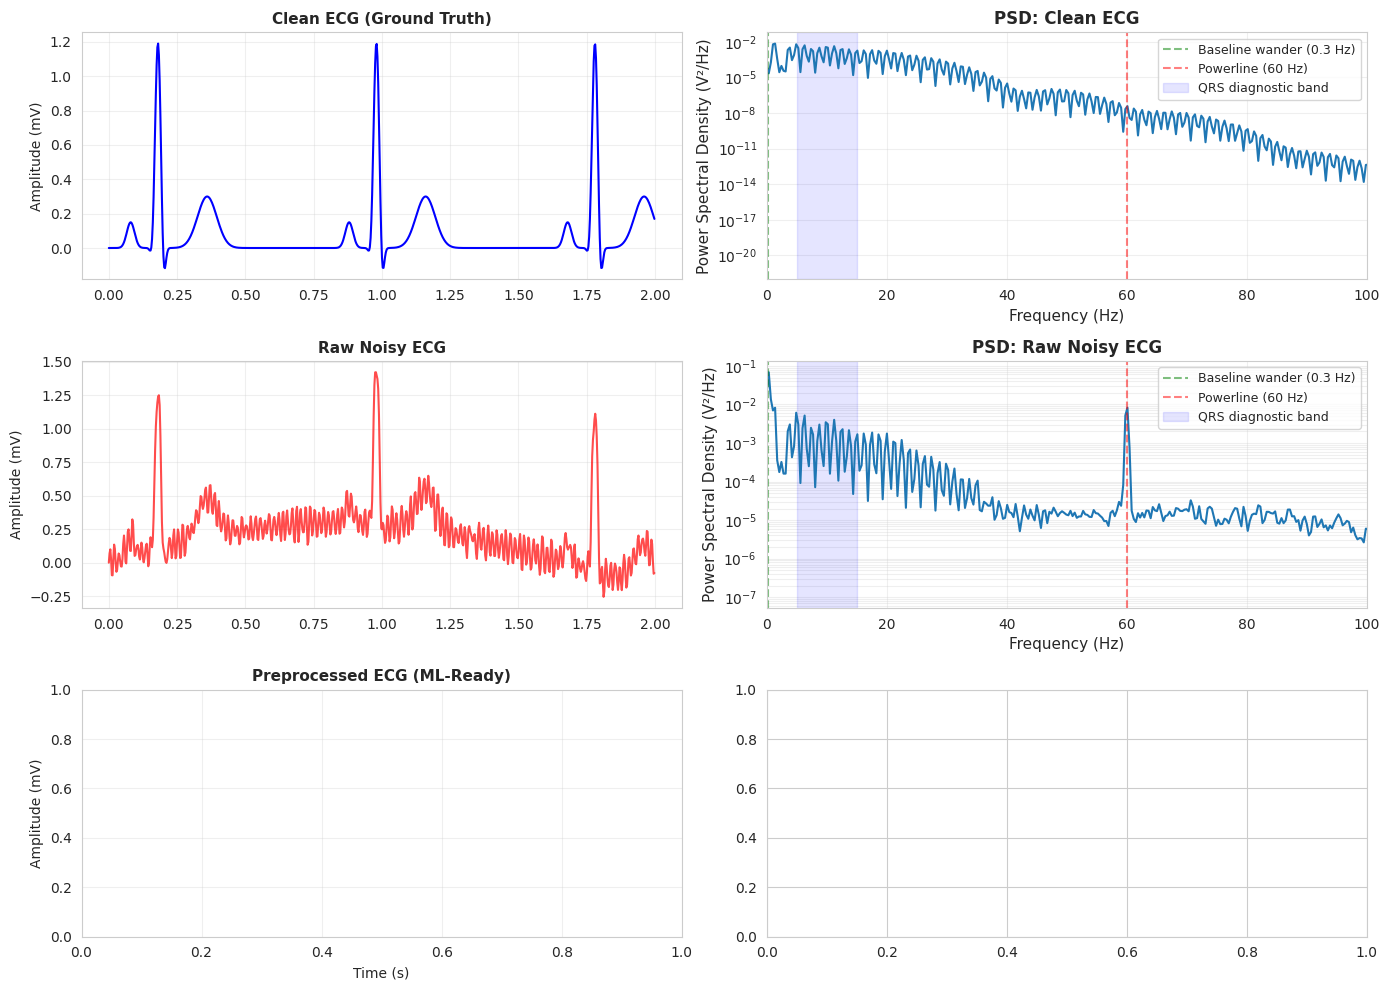


🎯 Key Observations:

📉 Time Domain:
   - Clean: Clear P-QRS-T complexes
   - Noisy: Obscured by baseline wander, powerline, and artifacts
   - Preprocessed: Restored morphology, ready for feature extraction

📊 Frequency Domain:
   - Clean: Energy concentrated in diagnostic band (5-15 Hz)
   - Noisy: Significant power at 60 Hz and low frequencies
   - Preprocessed: Noise suppressed, diagnostic band preserved


In [ ]:
# Final comparison: Clean, Noisy, Preprocessed
fig = plt.figure(figsize=(14, 10))

# Time domain comparison
ax1 = plt.subplot(3, 2, 1)
ax1.plot(t[0:720], ecg_clean[0:720], linewidth=1.5, color='blue')
ax1.set_title('Clean ECG (Ground Truth)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Amplitude (mV)', fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 2, 3)
ax2.plot(t[0:720], ecg_noisy[0:720], linewidth=1.5, color='red', alpha=0.7)
ax2.set_title('Raw Noisy ECG', fontsize=11, fontweight='bold')
ax2.set_ylabel('Amplitude (mV)', fontsize=10)
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 2, 5)
if ecg_final is not None:
    ax3.plot(t[0:720], ecg_final[0:720], linewidth=1.5, color='green')
ax3.set_title('Preprocessed ECG (ML-Ready)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Time (s)', fontsize=10)
ax3.set_ylabel('Amplitude (mV)', fontsize=10)
ax3.grid(True, alpha=0.3)

# Frequency domain comparison
ax4 = plt.subplot(3, 2, 2)
plot_psd(ecg_clean, fs, 'PSD: Clean ECG', ax=ax4)

ax5 = plt.subplot(3, 2, 4)
plot_psd(ecg_noisy, fs, 'PSD: Raw Noisy ECG', ax=ax5)

ax6 = plt.subplot(3, 2, 6)
if ecg_final is not None:
    plot_psd(ecg_final, fs, 'PSD: Preprocessed ECG', ax=ax6)

plt.tight_layout()
plt.show()

print("\n🎯 Key Observations:")
print("\n📉 Time Domain:")
print("   - Clean: Clear P-QRS-T complexes")
print("   - Noisy: Obscured by baseline wander, powerline, and artifacts")
print("   - Preprocessed: Restored morphology, ready for feature extraction")
print("\n📊 Frequency Domain:")
print("   - Clean: Energy concentrated in diagnostic band (5-15 Hz)")
print("   - Noisy: Significant power at 60 Hz and low frequencies")
print("   - Preprocessed: Noise suppressed, diagnostic band preserved")

## 8. Real-World Considerations

### 8.1 Modality-Specific Preprocessing

Different physiological signals require different preprocessing strategies:

| Modality | Common Noise | Filter Settings | Artifacts |
|----------|--------------|-----------------|------------|
| **ECG** | Baseline wander, powerline (50/60 Hz), EMG | Bandpass: 0.5-40 Hz, Notch: 50/60 Hz | Motion, electrode disconnection |
| **EEG** | Powerline, eye blinks, muscle activity | Bandpass: 0.5-50 Hz, Notch: 50/60 Hz | Eye artifacts (EOG), motion |
| **PPG** | Motion, ambient light, venous pulsations | Bandpass: 0.5-10 Hz | Motion artifacts (very common) |
| **Respiratory** | Baseline drift, movement | Highpass: 0.1 Hz | Coughing, talking |
| **Blood Pressure** | Transducer noise, catheter flushing | Lowpass: 20 Hz | Catheter flushing spikes |

### 8.2 Clinical Workflow Integration

**Preprocessing in production systems**:

1. **Real-time processing**:
   - Use causal filters (no future samples)
   - Accept slight phase delay
   - Buffer data for segment-based analysis

2. **Offline analysis**:
   - Use zero-phase filters (filtfilt)
   - More aggressive filtering
   - Manual review of rejected segments

3. **Quality assurance**:
   - Log quality metrics for all segments
   - Flag segments for manual review
   - Track false alarm rates

### 8.3 Common Pitfalls

⚠️ **Over-filtering**: Removing too much frequency content can distort diagnostic features (e.g., ST segment changes in myocardial infarction).

⚠️ **Phase distortion**: Using causal filters introduces phase delay, which can misalign features (use zero-phase filters when possible).

⚠️ **Adaptive thresholds**: Fixed artifact thresholds may fail for patients with different baseline characteristics (consider patient-specific calibration).

⚠️ **Filter order**: High-order filters have steep roll-off but can introduce ringing artifacts (start with order 4, increase cautiously).

### 8.4 Regulatory and Clinical Validation

**FDA and CE Mark requirements**:
- Document all preprocessing steps
- Validate filters on diverse patient populations
- Demonstrate that filtering does not remove diagnostic information
- Provide traceability (which segments were rejected and why)

**Clinical validation**:
- Compare automated preprocessing to expert manual review
- Measure false rejection rate (discarding usable data)
- Measure false acceptance rate (accepting unusable data)
- Test on diverse devices, electrode types, patient populations

## 9. Key Takeaways

### What We Learned

1. **Filtering is essential for physiological signals**
   - Notch filter removes powerline interference (50/60 Hz)
   - Highpass filter removes baseline wander (<0.5 Hz)
   - Lowpass filter removes high-frequency muscle noise (>40 Hz)
   - Bandpass filter combines highpass and lowpass (0.5-40 Hz for ECG)

2. **Signal quality assessment is critical**
   - SNR quantifies improvement (target: >20 dB)
   - Reference-free metrics (kurtosis, peak detection, power in noise bands)
   - Segment-based quality control for continuous monitoring

3. **Artifact detection prevents false alarms**
   - MAD-based thresholding detects motion artifacts
   - Segment rejection prevents corrupted data from reaching ML models
   - Decision thresholds balance sensitivity and specificity

4. **Complete pipeline is modular and reusable**
   - Preprocessing → Quality assessment → Artifact detection → Accept/Reject
   - Adapt parameters for different signal types (ECG, EEG, PPG)
   - Log quality metrics for clinical traceability

### Connections to Book Chapters

- **Journey 7.4**: ECG Classification with 1D CNNs (this preprocessing is a prerequisite)
- **Journey 7.3**: Sepsis Prediction (vital sign preprocessing uses similar techniques)
- **Chapter 5**: Evaluation (SNR and quality metrics are performance measures)

### Next Steps

In the next notebooks, we will:
- **Notebook 7.2**: Extract time-domain and frequency-domain features from preprocessed signals
- **Notebook 7.5**: Implement forecasting methods (ARIMA, LSTMs) for time series prediction
- **Notebook 7.6**: Build real-time processing pipelines for ICU monitoring

---

## Exercises

1. **Modify the filter cutoff frequencies**:
   - Try different highpass cutoffs (0.1 Hz, 0.5 Hz, 1.0 Hz)
   - Observe the effect on baseline wander removal
   - What happens if you set the cutoff too high?

2. **Implement a 50 Hz notch filter**:
   - Adapt the notch filter for European/Asian powerline frequency (50 Hz)
   - Compare the performance to the 60 Hz filter

3. **Test different artifact detection thresholds**:
   - Modify the `threshold_factor` parameter (2, 3, 4, 5)
   - Calculate sensitivity and specificity for artifact detection
   - What is the optimal threshold?

4. **Implement a sliding window quality assessment**:
   - Divide the signal into overlapping 5-second windows (50% overlap)
   - Calculate quality scores for each window
   - Plot quality over time

5. **Add a causal filter for real-time processing**:
   - Replace `filtfilt` (zero-phase) with `lfilter` (causal)
   - Observe the phase delay introduced
   - How does this affect R-peak detection?

6. **Extend to other modalities**:
   - Generate a synthetic EEG signal with eye blink artifacts
   - Adapt the preprocessing pipeline for EEG (bandpass: 0.5-50 Hz)
   - Implement EOG artifact removal

7. **Compare with real ECG data**:
   - Download the MIT-BIH Arrhythmia Database (https://physionet.org/content/mitdb/)
   - Apply the preprocessing pipeline to real ECG recordings
   - Validate quality metrics against expert annotations

---

*This notebook is part of "AI in Healthcare" (Volume 1)*  
*Full implementation available in the complete book companion code*